# QuDiPy Conditional Sequence Playback

Plays multiple pulse sequences simultaneously based on pulses generated with QuDiPy. Starts with the GHZ state prep, then into a readout sequence, followed by a simulated trigger and a conditional X gate. For this notebook, the outputs are being viewed on the LeCroy scope. The QRM outputs O1 and O2 are connected to inputs I1 and I2 respectively. QCM outputs O1, O2, O3 and O4 are connected to the scope. The scope should be set to 1MOhm input impedance.

Authors: Noah Stieler, Luke Dyer

In [1]:
import json

import numpy as np
import matplotlib.pyplot as plt

from qblox_instruments import Cluster
from qblox_instruments.types import InstrumentType

In [2]:
#Scan for clusters
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.6.2 with name "cluster-mm" and serial number 00015_2251_003


#### Configure and connect to Qblox modules

In [3]:
cluster = Cluster("cluster_mm", "192.168.137.2")
moduleQRM = None
moduleQCM = None

modules = [mod for mod in cluster.modules if mod.present()]
for mod in modules:
	print(str(mod) + " type=" + str(mod.module_type) + " is_rf_type=" + str(mod.is_rf_type))

cluster.reset()
cluster.get_system_state()

moduleQRM = modules[1]
moduleQCM = modules[0]

<QcmQrm: cluster_mm_module2 of Cluster: cluster_mm> type=QCM is_rf_type=False
<QcmQrm: cluster_mm_module4 of Cluster: cluster_mm> type=QRM is_rf_type=False
<QcmQrm: cluster_mm_module6 of Cluster: cluster_mm> type=QCM is_rf_type=True


#### Load in waveforms

In [4]:
def importWaveforms(filename: str, waveformNames: list[str], plotTitle: str) -> dict[str, list[float]]:
	pulseData = None
	with open(filename, encoding="utf-8") as file:
		pulseData = json.load(file)
		file.close()

	waveformDict = {
		waveformNames[0]: pulseData[waveformNames[0]],
		waveformNames[1]: pulseData[waveformNames[1]],
		waveformNames[2]: pulseData[waveformNames[2]],
		waveformNames[3]: pulseData[waveformNames[3]]}

	# Plot the pulses
	fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))
	ax.plot(waveformDict[waveformNames[0]], label=waveformNames[0])
	ax.plot(waveformDict[waveformNames[1]], label=waveformNames[1])
	ax.plot(waveformDict[waveformNames[2]], label=waveformNames[2])
	ax.plot(waveformDict[waveformNames[3]], label=waveformNames[3])
	ax.set_xlabel("Time [s]")
	ax.set_ylabel("Voltage [V]")
	ax.legend()
	ax.set_title(plotTitle)
	plt.show()

	return waveformDict

#### Configure QRM thresholding

This is to mimic an RF reflectometry measurement, and differentiate between two states that a qubit could be in. This is why the two state pulses differ by only a small amount, it creates a difference between the two demodulated signals which is then used for triggering. See modulation.ipynb for more information.\
Note: accounting for time of flight is important, so make sure to reference timeOfFlightComp.ipynb to see how it is determined.

In [5]:
cluster.reset()
cluster.get_system_state()

SystemState(status=<SystemStatus.OKAY>, flags=[], slot_flags=SystemStatusSlotFlags())

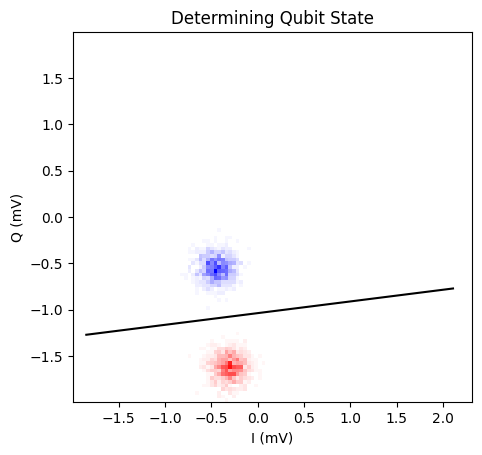

In [6]:
#Configure QRM for determining threshold values
integrationLength = 120
moduleQRM.sequencer0.integration_length_acq(integrationLength)
moduleQRM.sequencer0.nco_freq(50e6)	#This sets the modulation frequency
moduleQRM.sequencer0.mod_en_awg(True)
moduleQRM.sequencer0.demod_en_acq(True)
moduleQRM.disconnect_inputs()
moduleQRM.disconnect_outputs()
moduleQRM.sequencer0.connect_sequencer("io0_1")

tof = 144	#Time of flight in nanoseconds, see timeOfFlightComp.ipynb to detemine it.

waveformLengthQRM = 120
t = np.arange(-80, 81, 1)
sigma = 20
waveforms = {
	"state0_I": {"data": [0.001] * waveformLengthQRM, "index": 0},
	"state0_Q": {"data": [0.001] * waveformLengthQRM, "index": 1},
	"state1_I": {"data": [0.001] * waveformLengthQRM, "index": 2},
	"state1_Q": {"data": [0.003] * waveformLengthQRM, "index": 3},
}
acquisitions = {
	"state0": {"index": 0, "num_bins": 1024}, #Each bin stores an integration result
	"state1": {"index": 1, "num_bins": 1024}
}

#Store the integrated result of each modulated signal, and repeat 1024 times
sequenceProgram = f"""
	move			0,R0

	start:
		play		0,1,{tof}
		acquire		0,R0,{waveformLengthQRM}
		play		2,3,{tof}
		acquire	1,R0,{waveformLengthQRM}
		add			R0,1,R0
		wait		4000
		jlt			R0,1024,@start

	upd_param	4
	stop

"""

sequence = {
	"waveforms": waveforms,
	"weights": {},
	"acquisitions": acquisitions,
	"program": sequenceProgram
}
moduleQRM.sequencer0.sequence(sequence)

moduleQRM.arm_sequencer(0)
moduleQRM.start_sequencer()

moduleQRM.get_acquisition_state(0, 1)
moduleQRM.store_scope_acquisition(0, "state0")
moduleQRM.store_scope_acquisition(0, "state1")
data = moduleQRM.get_acquisitions(0)

'''We don't take the actual integration values (ie state0/integration length) because the only relevant
information here is the difference between the two states, not the actual data points themselves.'''
state0 = np.array(data["state0"]["acquisition"]["bins"]["integration"]["path0"]) + 1j *np.array(
	data["state0"]["acquisition"]["bins"]["integration"]["path1"])
state1 = np.array(data["state1"]["acquisition"]["bins"]["integration"]["path0"]) + 1j *np.array(
	data["state1"]["acquisition"]["bins"]["integration"]["path1"])

'''#Rotation and threshold values define a line which delineates between state0 and state1
The rotation value is the angle measured from the vertical axis, the threshold is the length of the
vector that is normal to the line, starting at the origin.

More information: https://qblox-qblox-instruments.readthedocs-hosted.com/en/main/cluster/q1_sequence_processor.html

Modulo operation is to ensure final angle is on the interval [0, 2pi].'''
rotation = np.mod(-np.angle(np.mean(state1) - np.mean(state0)), 2 * np.pi)

'''Once vetical line has been rotated, it needs to be offset. We rotate the mean
vector of the two points to get the threshold. To understand this, instead of thinking of
rotating the vector in the CCW direction, instead rotate the IQ axis in the CW direction. Then 
the distance between the mean and the rotated line is the real part of the mean.'''
averageVec = (np.mean(state1) + np.mean(state0))/2
threshold = (np.exp(1j*rotation) * averageVec).real

#Plotting the histogram
scaling = 1000 / integrationLength
maxr = max(np.max(np.abs(state0)), np.max(np.abs(state1)))
hist0, xedges, yedges = np.histogram2d(
    state0.real, state0.imag, range=((-maxr, maxr), (-maxr, maxr)), bins=100
)
hist1, xedges, yedges = np.histogram2d(
    state1.real, state1.imag, range=((-maxr, maxr), (-maxr, maxr)), bins=100
)

plt.imshow(
    1 - np.array((hist0, hist0 + hist1, hist1)).transpose(2, 1, 0) / np.max(hist0 + hist1),
    extent=(-maxr * scaling, maxr * scaling, -maxr * scaling, maxr * scaling),
    origin="lower",
)
plt.plot(
    ((1j * xedges + threshold) * np.exp(-1j * rotation)).real * scaling,
    ((1j * xedges + threshold) * np.exp(-1j * rotation)).imag * scaling,
    "k",
)
plt.xlabel("I (mV)")
plt.ylabel("Q (mV)")
plt.title("Determining Qubit State")
plt.show()

#### Configure and play entire conditional sequence

In [7]:
cluster.reset()
cluster.get_system_state()

SystemState(status=<SystemStatus.OKAY>, flags=[], slot_flags=SystemStatusSlotFlags())

In [8]:
'''Need all 6 sequencers. Each sequencer can play up to 16 us of waveform so to play all of these need to each play one of the pulse sequences.
Technically in this experiment the GHZ and Ancilla could be concatenated and played on one sequencer.'''
moduleQCM.disconnect_outputs()
moduleQCM.sequencer0.connect_sequencer("out0_1")
moduleQCM.sequencer1.connect_sequencer("out2_3")
moduleQCM.sequencer2.connect_sequencer("out0_1")
moduleQCM.sequencer3.connect_sequencer("out2_3")
moduleQCM.sequencer4.connect_sequencer("out0_1")
moduleQCM.sequencer5.connect_sequencer("out2_3")
moduleQCM.sequencer0.sync_en(True)						#Enable wait_sync Q1ASM instruction
moduleQCM.sequencer1.sync_en(True)
moduleQCM.sequencer2.sync_en(True)
moduleQCM.sequencer3.sync_en(True)
moduleQCM.sequencer4.sync_en(True)
moduleQCM.sequencer5.sync_en(True)


moduleQRM.sequencer0.integration_length_acq(integrationLength)
moduleQRM.sequencer0.nco_freq(50e6)	#This sets the modulation frequency
moduleQRM.sequencer0.mod_en_awg(True)
moduleQRM.sequencer0.demod_en_acq(True)
moduleQRM.disconnect_inputs()
moduleQRM.disconnect_outputs()
moduleQRM.sequencer0.connect_sequencer("io0_1")
moduleQRM.sequencer0.thresholded_acq_threshold(threshold)
moduleQRM.sequencer0.thresholded_acq_rotation(rotation * 360 / (2 * np.pi))#Convert to degrees
moduleQRM.sequencer0.thresholded_acq_trigger_address(1)
moduleQRM.sequencer0.thresholded_acq_trigger_en(True)
moduleQRM.sequencer0.sync_en(True)

cluster.reset_trigger_monitor_count(address=1)
moduleQRM.sequencer0.delete_acquisition_data(all=True)

#### Importing and Making Waveform Dictionaries

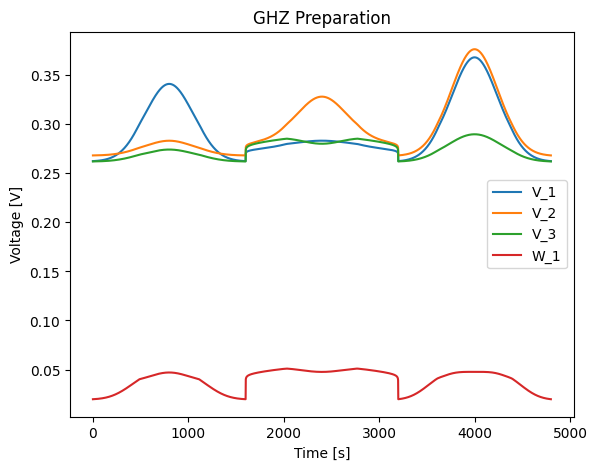

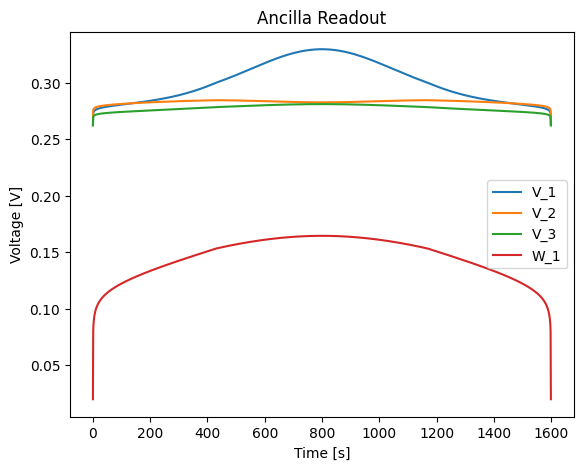

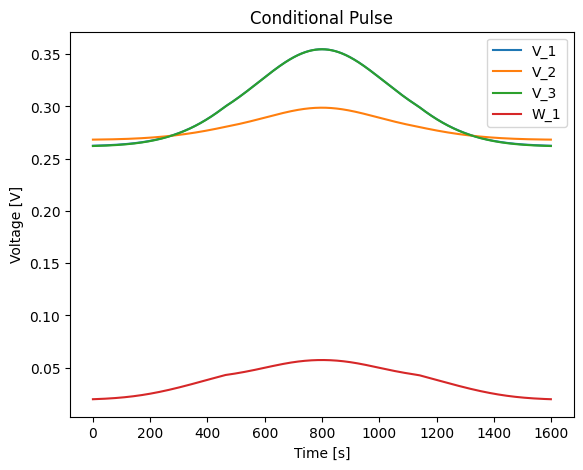

In [9]:
waveformGHZ = importWaveforms("GHZ_prep_example_nodeA.json", ["V_1", "V_2", "V_3", "W_1"], "GHZ Preparation")
waveformAncilla = importWaveforms("Ancilla_readout_example_nodeA.json", ["V_1", "V_2", "V_3", "W_1"], "Ancilla Readout")
waveformCond = importWaveforms("conditional_A1_gate_post_readout_example_nodeA.json", ["V_1", "V_2", "V_3", "W_1"], "Conditional Pulse")

In [10]:
# Waveform dictionarys for GHZ sequencers
GHZWaveformsSequencer0 = {
	"GHZ_V_1" : {"data": (np.array(waveformGHZ["V_1"]) / 5).tolist(), "index": 0},
	"GHZ_W_2" : {"data": (np.array(waveformGHZ["V_2"]) / 5).tolist(), "index": 1}
}
GHZWaveformsSequencer1 = {
	"GHZ_V_3" : {"data": (np.array(waveformGHZ["V_3"]) / 5).tolist(), "index": 0},
	"GHZ_W_1" : {"data": (np.array(waveformGHZ["W_1"]) / 5).tolist(), "index": 1}
}

# Waveform dictionarys for Ancilla sequencers
AnciWaveformsSequencer2 = {
	"Anci_V_1" : {"data": (np.array(waveformAncilla["V_1"]) / 5).tolist(), "index": 0},
	"Anci_W_2" : {"data": (np.array(waveformAncilla["V_2"]) / 5).tolist(), "index": 1}
}
AnciWaveformsSequencer3 = {
	"Anci_V_3" : {"data": (np.array(waveformAncilla["V_3"]) / 5).tolist(), "index": 0},
	"Anci_W_1" : {"data": (np.array(waveformAncilla["W_1"]) / 5).tolist(), "index": 1}
}

# Waveform dictionarys for Conditional sequencers
CondWaveformsSequencer4 = {
	"Cond_V_1" : {"data": (np.array(waveformCond["V_1"]) / 5).tolist(), "index": 0},
	"Cond_W_2" : {"data": (np.array(waveformCond["V_2"]) / 5).tolist(), "index": 1}
}
CondWaveformsSequencer5 = {
	"Cond_V_3" : {"data": (np.array(waveformCond["V_3"]) / 5).tolist(), "index": 0},
	"Cond_W_1" : {"data": (np.array(waveformCond["W_1"]) / 5).tolist(), "index": 1}
}


#### Making sequence programs

In [11]:
# Get the waveform length for the GHZ sequence
GHZWaveformLength = len(waveformGHZ["V_1"])

# Program for both the GHZ sequencers
GHZSequence = f"""
		wait_sync	4
		play		0,1,{GHZWaveformLength}	
		stop
	"""

In [12]:
# Get the waveform length for the Ancilla Sequence
anciWaveformLength = len(waveformAncilla["V_1"])

# Program for the ancilla sequencers
anciSequence = f"""
		wait_sync	4
		wait		{GHZWaveformLength + 1000} # Wait for the GHZ waveform to play before playing this pulse
		play		0,1,{anciWaveformLength}	
		stop
	"""

In [13]:
# Get the waveform length for the conditional sequence
condWaveformLength = len(waveformCond["V_1"])

# Program for conditional sequence
condSequence = f"""
	set_latch_en	1,4	#Enable listening to triggers on address 1
	wait_sync		4

	wait			{GHZWaveformLength + anciWaveformLength + 1000} # Wait for both GHZ and Ancillary pulses to play

	#Delete all the previously received triggers
	#Then wait for the QRM pulse to play
	latch_rst		{tof+waveformLengthQRM}
	wait			300		#Makes sure acquisition has been received by the QRM

	set_cond	1, 1, 0, 700			#Enables conditionality dependent upon trigger 1
	play		0, 1, {condWaveformLength}
	set_cond	0, 1, 0, 700			#Disables the conditionality

	stop
"""

#### Making QRM Program

In [14]:
#Change QRM sequence to play only one waveform and thus trigger once
stateControl = False

sequenceProgram = ""

if stateControl:
	sequenceProgram = f"""
		wait_sync	4
		wait		{GHZWaveformLength + anciWaveformLength + 1000}
		play		2,3,{tof}
		acquire		1,0,{waveformLengthQRM}
		stop
	"""
else:
	sequenceProgram = f"""
		wait_sync	4
		wait		{GHZWaveformLength + anciWaveformLength + 1000}
		play		0,1,{tof}
		acquire		0,0,{waveformLengthQRM}
		stop
	"""
moduleQRM.sequencer0.sequence({
	"waveforms": waveforms,"weights": {},"acquisitions": acquisitions,"program": sequenceProgram})

In [15]:
# Upload the JSON files
moduleQCM.sequencer0.sequence({"waveforms": GHZWaveformsSequencer0,"weights": {},"acquisitions": {},"program": GHZSequence})
moduleQCM.sequencer1.sequence({"waveforms": GHZWaveformsSequencer1,"weights": {},"acquisitions": {},"program": GHZSequence})
moduleQCM.sequencer2.sequence({"waveforms": AnciWaveformsSequencer2,"weights": {},"acquisitions": {},"program": anciSequence})
moduleQCM.sequencer3.sequence({"waveforms": AnciWaveformsSequencer3,"weights": {},"acquisitions": {},"program": anciSequence})
moduleQCM.sequencer4.sequence({"waveforms": CondWaveformsSequencer4,"weights": {},"acquisitions": {},"program": condSequence})
moduleQCM.sequencer5.sequence({"waveforms": CondWaveformsSequencer5,"weights": {},"acquisitions": {},"program": condSequence})
moduleQCM.arm_sequencer(0)
moduleQCM.arm_sequencer(1)
moduleQCM.arm_sequencer(2)
moduleQCM.arm_sequencer(3)
moduleQCM.arm_sequencer(4)
moduleQCM.arm_sequencer(5)
moduleQRM.arm_sequencer(0)

moduleQCM.start_sequencer()
moduleQRM.start_sequencer()

print(moduleQCM.get_sequencer_state(0))
print(moduleQCM.get_sequencer_state(1))

print("Trigger events: ", cluster.trigger1_monitor_count())

Status: STOPPED, Flags: NONE
Status: STOPPED, Flags: NONE
Trigger events:  0
